# Louisiana Parish Cancer & Income Analysis
### Analyzing Socioeconomic Patterns in Louisiana Public Health

## Key Findings

- afdafa
- fasdf
- adf

## Research Question

Is there a meaningful relationship statistically between cancer incidence rates and median household income across Louisiana Parishes?

## Data Sources

- Louisiana Cancer Incidence Rates (2018-2022)
    - https://statecancerprofiles.cancer.gov/incidencerates/index.php?statefips=22&areatype=county&cancer=001&race=00&sex=0&age=001&ruralurban=0&type=incd#results
- S1901 | Income in the Past 12 Months (in 2022 Inflation-Adjusted Dollars)
    - https://data.census.gov/table/ACSST5Y2022.S1901?q=Median+household+income+Louisiana+parish+ACS+5-year&g=040XX00US22$0500000&y=2022&moe=false&tp=false&tableFilters=ag-Grid-AutoColumn~(Margin+of+Errorundefined)
- Louisiana Parish Shapefile
    - https://virtual.la.gov/datasets/louisiana-parishes/explore?location=30.936899%2C-91.400771%2C7

### Imports Used

In [139]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import os

# To ensure the folder exists
os.makedirs("../reports/figures", exist_ok=True)

### Head of the Merged Dataset CSV

In [128]:
df = pd.read_csv("../data/processed/merged-clean.csv")

df.head()

,Parish,cancer_rate,median_income
0,Cameron,325.2,69847
1,Iberville,318.0,59410
2,Claiborne,309.4,32034
3,Red River,298.9,43821
4,Franklin,293.3,41129


### Datatypes and Statistics Information of CSV

In [129]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Parish         64 non-null     str    
 1   cancer_rate    64 non-null     float64
 2   median_income  64 non-null     int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 1.6 KB


,cancer_rate,median_income
count,64.000000,64.000000
mean,262.710938,53126.265625
std,22.221712,13819.406035
min,214.300000,30856.000000
25%,246.550000,43316.500000
50%,259.650000,50961.000000
75%,277.025000,62981.500000
max,325.200000,93800.000000


### Correlation Analysis

The correlation between median incomes and cancer incidence rates is weakly negative (r ≈ 0.18).

In [130]:
correlation = df["median_income"].corr(df["cancer_rate"])
correlation

np.float64(-0.17660181914318096)

### Regression Analysis

- Intercept: The predicted cancer incidence rate when income equals 0.
- Slope: How much cancer incidence rate changes per $1 increase on income.
    - Slope is negative [-0.00028398] so when income increases, cancer decreases
- \$R^2\$: How much median household income correlates with cancer.
    - Income explains around 3% of cancer variation

In [138]:
X = df[["median_income"]]
y = df["cancer_rate"]

regression_model = LinearRegression()
regression_model.fit(X, y)

intercept = regression_model.intercept_
slope = regression_model.coef_
r_squared = regression_model.score(X, y)

print("Intercept:", intercept)
print("Slope:", slope)
print("R-squared:", r_squared)

Intercept: 277.79757997713256
Slope: [-0.00028398]
R-squared: 0.031188202524680908


### Income vs Cancer Incidence Rate (High vs Low Income Parishes) Scatterplot

- Parishes were split into two income groups, high and low income based on the median income cutoff.
- Lower income parishes show slightly higher concentration of cancer incidence rate; however, substantial overlap exists between two groups.
- This could suggest that income may be a factor in cancer incidence rate, but is not a strong standalone predictor.

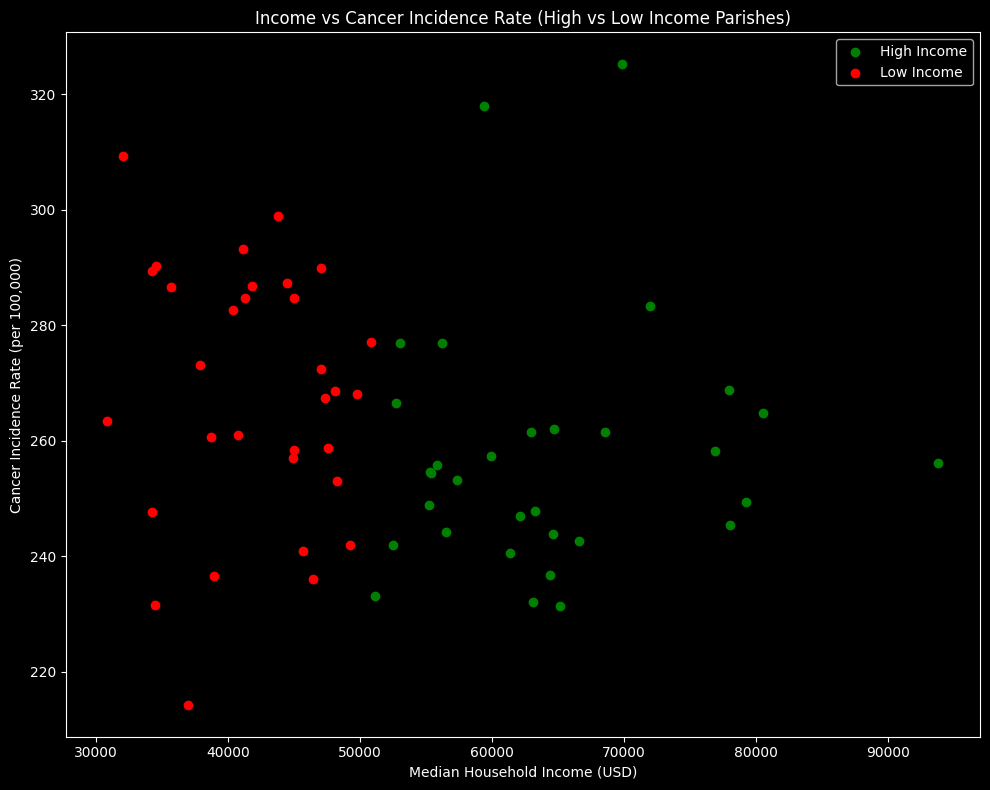

Median Cutoff: 50961.0
High Income Count: 32
Low Income Count: 32


In [149]:
median_income_cutoff = df["median_income"].median()

high_income = df[df["median_income"] >= median_income_cutoff]
low_income = df[df["median_income"] < median_income_cutoff]

plt.figure(figsize=(10, 8))

plt.scatter(high_income["median_income"],
            high_income["cancer_rate"],
            color="green",
            label="High Income"
)

plt.scatter(low_income["median_income"],
            low_income["cancer_rate"],
            color="red",
            label="Low Income"
)

plt.xlabel("Median Household Income (USD)")
plt.ylabel("Cancer Incidence Rate (per 100,000)")
plt.title("Income vs Cancer Incidence Rate (High vs Low Income Parishes)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/scatter_income_cancer_hl.png", dpi=300)
plt.show()

print("Median Cutoff:", median_income_cutoff)
print("High Income Count:", len(high_income))
print("Low Income Count:", len(low_income))

### Income vs Cancer Incidence Rate Scatterplot with Trendline

- This scatterplot shows relationship between median household income and cancer incidence rate across Louisiana parishes.
    - Each points is a parish with color indicating cancer intensity.
    - Trendline indicates a week negative association between median income and cancer rates.
- Having correlation r ≈ -0.18, meaning income only explains small portion of cancer rates.

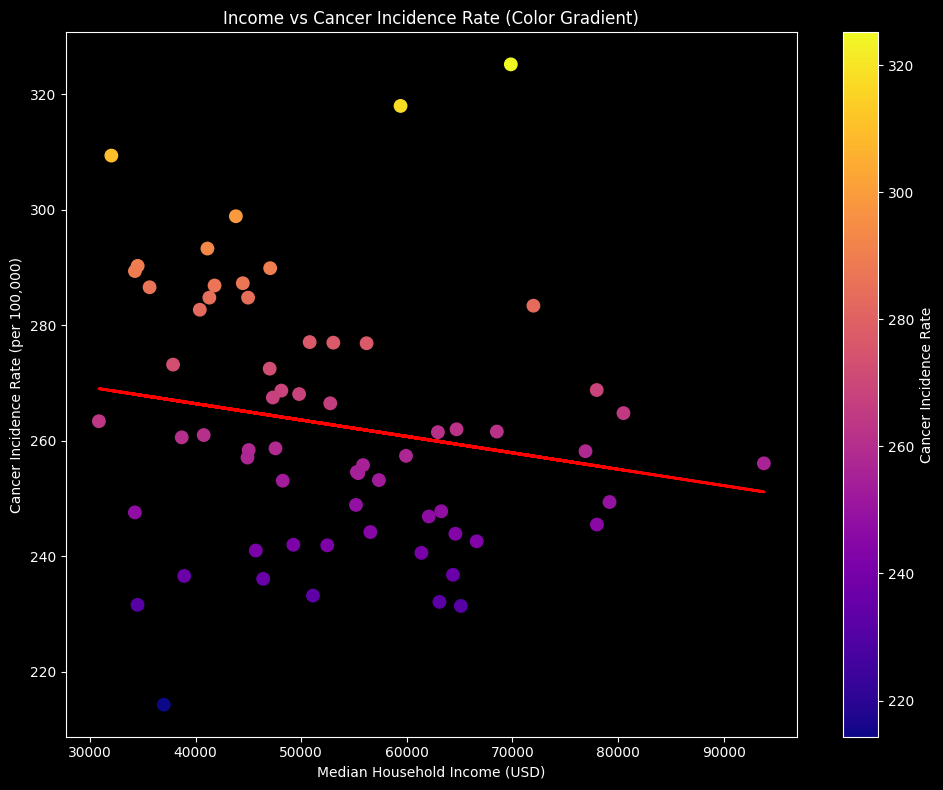

In [150]:
m, b = np.polyfit(df["median_income"], df["cancer_rate"], 1)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    df["median_income"],
    df["cancer_rate"],
    c=df["cancer_rate"],
    cmap="plasma",
    s=80
)

plt.plot(
    df["median_income"],
    m * df["median_income"] + b,
    color="red",
    linewidth=2
)

plt.colorbar(scatter, label="Cancer Incidence Rate")
plt.xlabel("Median Household Income (USD)")
plt.ylabel("Cancer Incidence Rate (per 100,000)")
plt.title("Income vs Cancer Incidence Rate (Color Gradient)")
plt.tight_layout()
plt.savefig("../reports/figures/scatter_income_cancer.png", dpi=300)
plt.show()

### Top 10 Parishes with the Highest Cancer rates

- Shows the top 10 Parish with the highest cancer incidence rates in a bar chart.

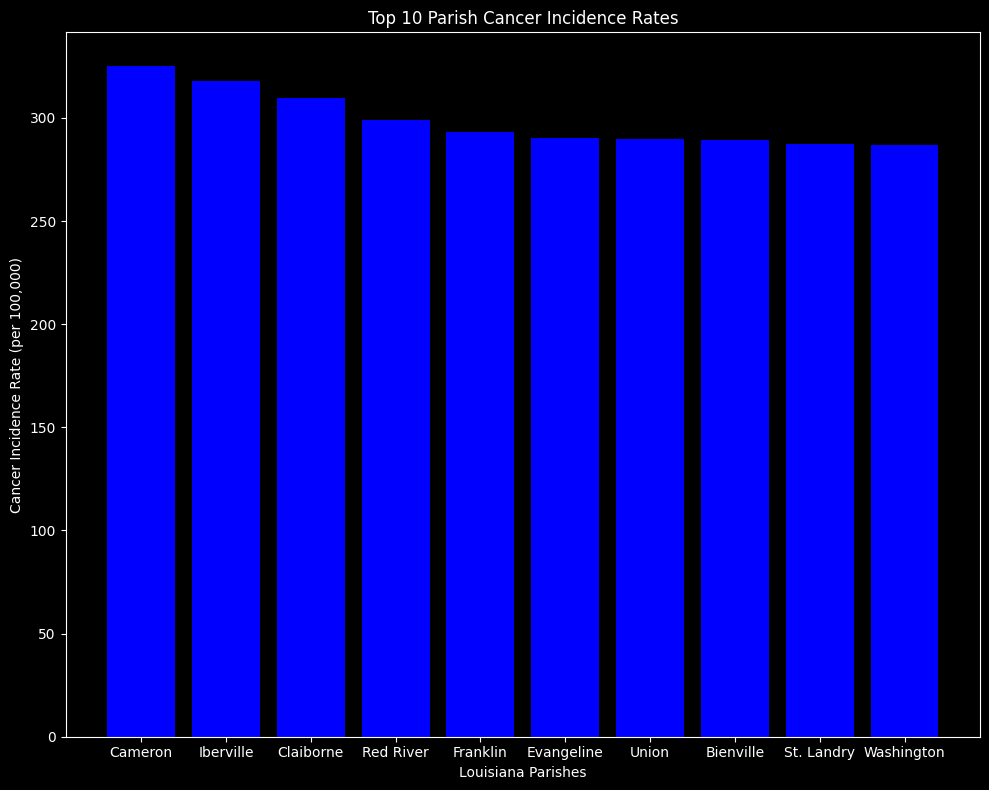

In [151]:
top_ten_parishes = df.sort_values("cancer_rate", ascending=False).head(10)

plt.figure(figsize=(10,8))

plt.bar(top_ten_parishes["Parish"],
        top10["cancer_rate"],
        color="blue",
        label="Top 10 Parishes"
)

plt.xlabel("Louisiana Parishes")
plt.ylabel("Cancer Incidence Rate (per 100,000)")
plt.title("Top 10 Parish Cancer Incidence Rates")
plt.tight_layout()
plt.savefig("../reports/figures/top10_parish_cancer.png", dpi=300)
plt.show()

## Geospatial Analysis

Exploring spatial patterns, parish level cancer rates and incomes were mapped onto a choropleth visualization.

### Louisiana Cancer Incidence Rates Choropleth Map

- This choropleth map displays cancer incidence rates across Louisiana parishes.
- The map highlights regional variation in cancer incidence, with certain rural and industrial corridor areas exhibiting elevated rates.

/Users/jaycock/Development/Python-Projects/Louisiana-Cancer-Analysis/.venv/lib/python3.14/site-packages/pyogrio/raw.py:200: RuntimeWarning: ../data/raw/louisiana-shapefiles/Louisiana_Parishes.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


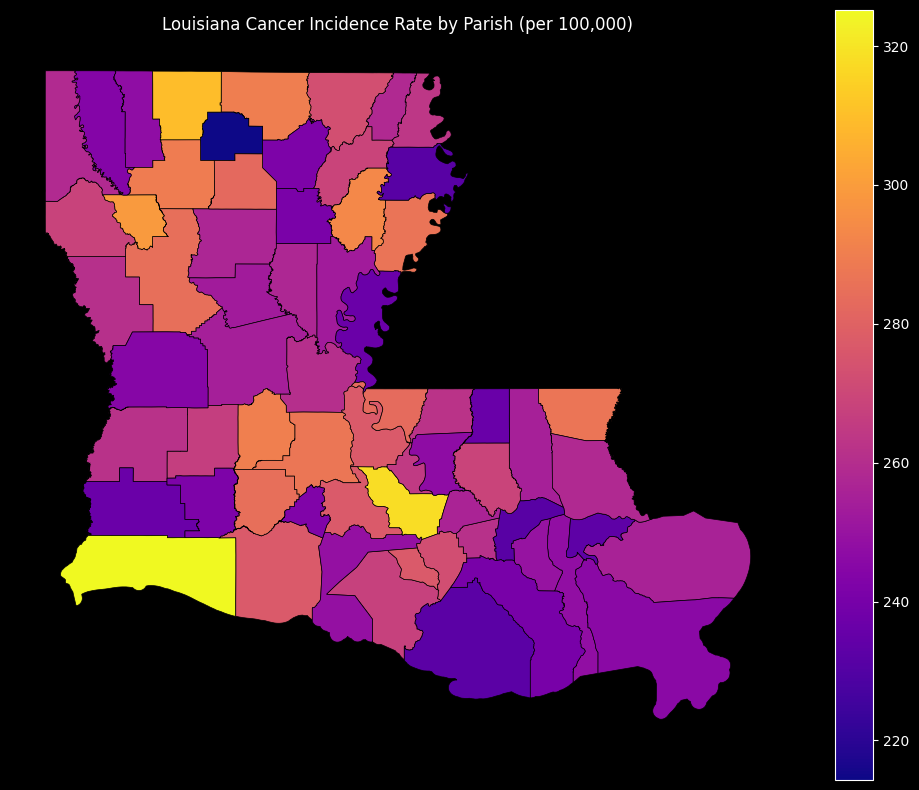

In [152]:
gdf = gpd.read_file("../data/raw/louisiana-shapefiles")

gdf["merge_key"] = (
    gdf["Name"]
    .str.lower()
    .str.replace(" ", "", regex=False)
)

df["merge_key"] = (
    df["Parish"]
    .str.lower()
    .str.replace(" ", "", regex=False)
)

map_df = gdf.merge(df, on="merge_key", how="inner")

ax = map_df.plot(
    column="cancer_rate",
    cmap="plasma",
    legend=True,
    figsize=(10, 8),
    edgecolor="black",
    linewidth=0.5,
)

ax.set_axis_off()
ax.set_title("Louisiana Cancer Incidence Rate by Parish (per 100,000)")
plt.tight_layout()
plt.savefig("../reports/figures/map_cancer.png", dpi=300)
plt.show()

### Louisiana Median Household Income Choropleth Map

- This choropleth maps displays median household incomes across Louisiana parishes.
- Income distribution shows clustering in suburban and urban regions, contrasting with lower income concentrations in rural areas.

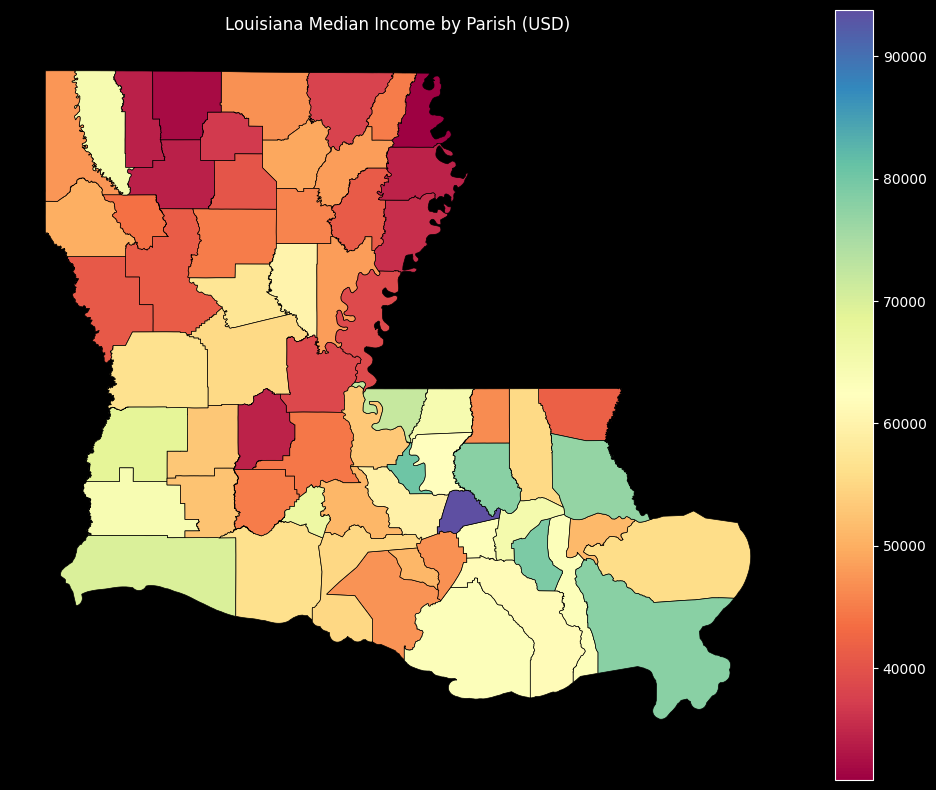

In [153]:
ax = map_df.plot(
    column="median_income",
    cmap="Spectral",
    legend=True,
    figsize=(10, 8),
    edgecolor="black",
    linewidth=0.5,
)

ax.set_axis_off()
ax.set_title("Louisiana Median Income by Parish (USD)")
plt.tight_layout()
plt.savefig("../reports/figures/map_income.png", dpi=300)
plt.show()

### Louisiana Residuals by Parish (Actual - Predicted) Choropleth Maps

- This choropleth map shows which parishes have unusually high cancer incidence rates after controlling for median income.
- This visualization isolates variation in cancer incidence that cannot be explained by income alone.

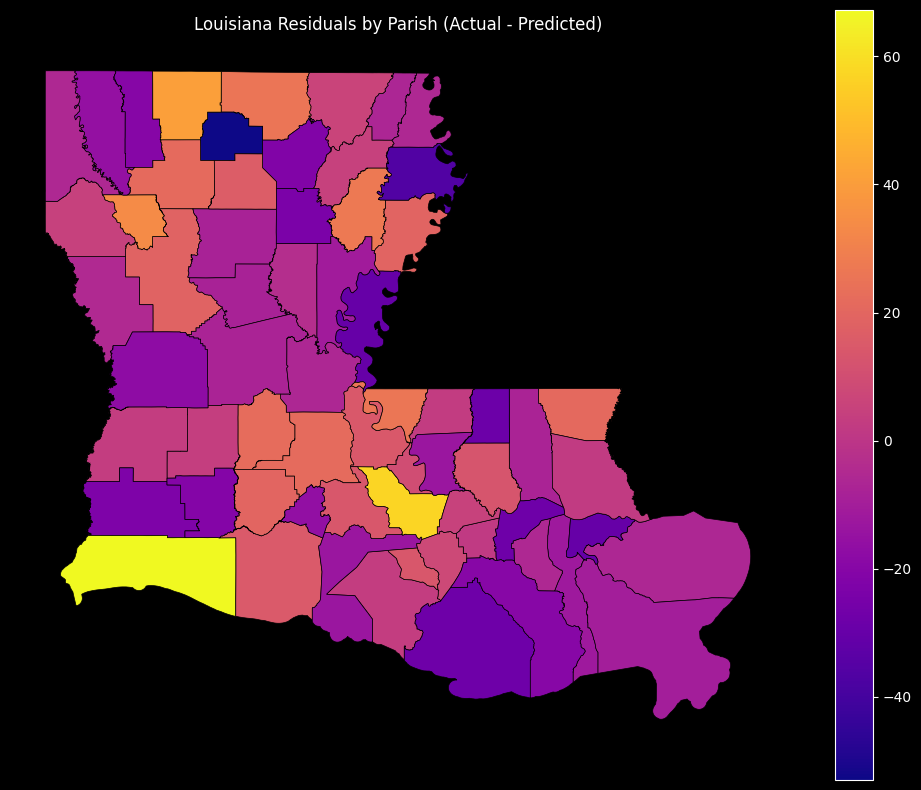

In [154]:
predict_model = LinearRegression()
predict_model.fit(X,y)

df["predicted_cancer_rate"] = predict_model.predict(X)

df["residual"] = df["cancer_rate"] - df["predicted_cancer_rate"]

map_df = gdf.merge(df,
                   on="merge_key",
                   how="inner"
)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

map_df.plot(
    column="residual",
    cmap="plasma",
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.5,
)

ax.set_axis_off()
ax.set_title("Louisiana Residuals by Parish (Actual - Predicted)")
plt.tight_layout()
plt.savefig("../reports/figures/map_residual.png", dpi=300)
plt.show()

## Geospatial Analysis Findings (Choropleth maps)

- The spatial clustering suggests that elevated cancer incidence is concentrated in specific regions, while the median household income have a different pattern geographically.
- There is a lack of strong alignment between income and cancer hotspots.

## Conclusion

-